目标时间: 216000 s, 实际绘图时间: 216000.0 s (索引: 240)


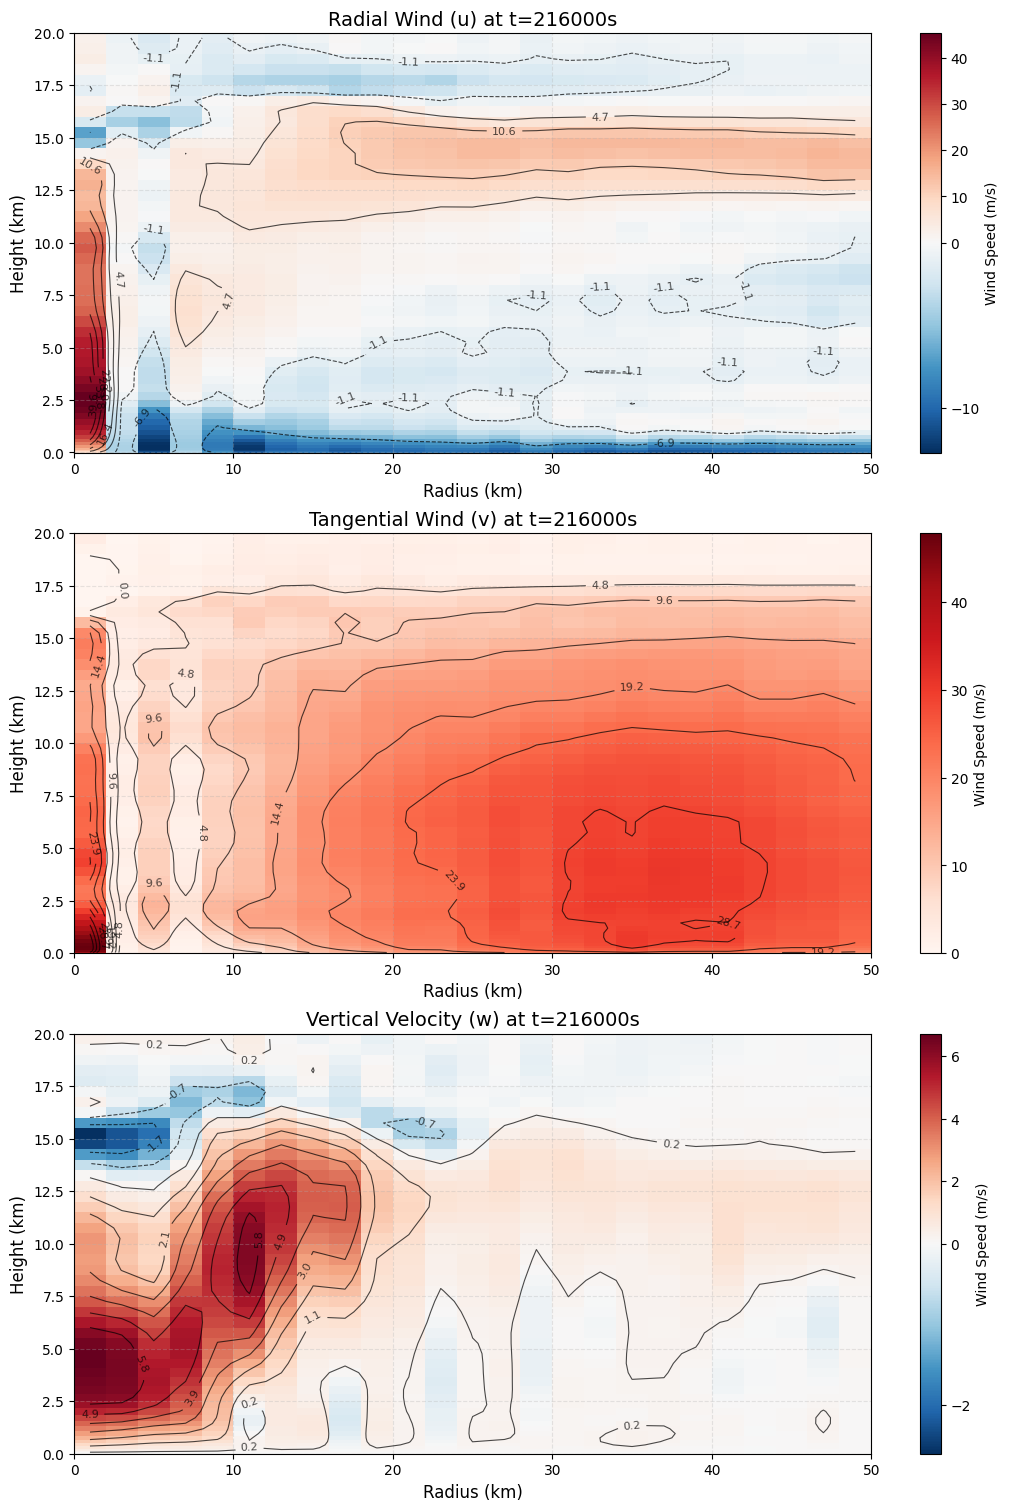

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import TwoSlopeNorm, PowerNorm

# --------------------------
# 1. 参数设置
# --------------------------
nc_file = "dataset/typhoon_azimuthal_avg_dynamic.nc"  # 方位角平均后的数据文件
target_time = 60*3600    # 指定时间 (单位: 秒)
max_r_km = 300.0       # 最大绘图半径 (km)
max_z_km = 20.0         # 最大绘图高度 (km)

# 手动设置 Colorbar 范围 (格式: [min, max], 设为 None 则自动计算)
u_clim = None   # 例如 [-20, 20]
v_clim = None   # 例如 [0, 80]
w_clim = None   # 例如 [-2, 2]

# 手动设置 Colorbar 渐变指数 (Gamma Correction)
# gamma = 1.0 (线性), gamma < 1.0 (增强小值对比), gamma > 1.0 (增强大值对比)
# 注: 目前主要用于 v (切向风)。u 和 w 为保持 0 点对齐，建议保持 1.0 (线性)
u_gamma = 0.5 
v_gamma = 1.0 
w_gamma = 1.0

# --------------------------
# 2. 读取数据并筛选范围
# --------------------------
with Dataset(nc_file, 'r') as nc:
    # 读取坐标
    time_arr = nc.variables['time'][:]
    r_arr = nc.variables['r'][:]  # km
    z_arr = nc.variables['z'][:]  # km (假设单位是km，如果是m请除以1000)

    # 找到最近的时间索引
    t_idx = np.argmin(np.abs(time_arr - target_time))
    actual_time = time_arr[t_idx]
    print(f"目标时间: {target_time} s, 实际绘图时间: {actual_time} s (索引: {t_idx})")

    # 创建空间筛选掩码 (Mask)
    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    
    # 提取筛选后的坐标
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]
    
    # 提取对应时间、对应空间范围的数据
    # 维度顺序假设为 (time, z, r)
    u_data = nc.variables['u'][t_idx, z_mask, r_mask]
    v_data = nc.variables['v'][t_idx, z_mask, r_mask]
    w_data = nc.variables['w'][t_idx, z_mask, r_mask]

# --------------------------
# 3. 绘图逻辑
# --------------------------
# 创建网格
R, Z = np.meshgrid(r_plot, z_plot)

fig, axes = plt.subplots(3, 1, figsize=(10, 15), constrained_layout=True)

# 定义绘图列表配置
plot_configs = [
    {
        "data": u_data,
        "title": f"Radial Wind (u) at t={actual_time:.0f}s",
        "cmap": "RdBu_r",  # 径向风通常有正负，用红蓝
        "ax": axes[0],
        "clim": u_clim,
        "gamma": u_gamma
    },
    {
        "data": v_data,
        "title": f"Tangential Wind (v) at t={actual_time:.0f}s",
        "cmap": "Reds",     # 切向风用红色深浅表示
        "ax": axes[1],
        "clim": v_clim,
        "gamma": v_gamma
    },
    {
        "data": w_data,
        "title": f"Vertical Velocity (w) at t={actual_time:.0f}s",
        "cmap": "RdBu_r",  # 垂直风有升有降，用红蓝
        "ax": axes[2],
        "clim": w_clim,
        "gamma": w_gamma
    }
]

for config in plot_configs:
    ax = config["ax"]
    data = config["data"]
    gamma = config["gamma"]
    
    # 1. 确定 Colorbar 范围
    if config["clim"] is not None:
        vmin, vmax = config["clim"]
    else:
        vmin = np.min(data)
        vmax = np.max(data)

    # 2. 针对不同变量的 Colorbar 策略
    norm = None
    plot_kwargs = {'cmap': config['cmap'], 'shading': 'auto'}
    
    # 用于 contour 的范围
    c_vmin, c_vmax = vmin, vmax

    if config["cmap"] == "RdBu_r":
        # u, w: 0值对应白色，非对称范围
        # 确保范围包含 0
        vmin = min(vmin, 0)
        vmax = max(vmax, 0)
        
        # 处理全正或全负的边界情况，TwoSlopeNorm 要求 vmin < vcenter < vmax
        if vmin == 0: vmin = -1e-5 * (vmax if vmax != 0 else 1.0)
        if vmax == 0: vmax = -1e-5 * (vmin if vmin != 0 else 1.0)
            
        # 注意：TwoSlopeNorm 是分段线性的，不支持 gamma 参数。
        # 如果强行需要非线性且保持0点对齐，需要自定义 Norm，这里保持线性以确保准确性。
        norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
        plot_kwargs['norm'] = norm
        c_vmin, c_vmax = vmin, vmax
    
    elif config["cmap"] == "Reds":
        # v: 0值对应白色(Reds起点)，只显示正值强度
        vmin = 0 # 强制下限为 0
        if config["clim"] is not None: vmax = config["clim"][1]
        
        # 支持 Gamma 校正
        if gamma != 1.0:
            norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
            plot_kwargs['norm'] = norm
        else:
            plot_kwargs['vmin'] = vmin
            plot_kwargs['vmax'] = vmax
            
        c_vmin, c_vmax = vmin, vmax
    
    else:
        plot_kwargs['vmin'] = vmin
        plot_kwargs['vmax'] = vmax

    # 3. 绘制填色图 (Pcolormesh)
    mesh = ax.pcolormesh(R, Z, data, **plot_kwargs)
    
    # 4. 绘制等值线 (Contour)
    # 自动选择合适的等值线间隔
    levels = np.linspace(c_vmin, c_vmax, 11) 
    cs = ax.contour(R, Z, data, levels=levels, colors='black', linewidths=0.8, alpha=0.7)
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
    
    # 5. 设置标签和 Colorbar
    ax.set_title(config["title"], fontsize=14)
    ax.set_ylabel('Height (km)', fontsize=12)
    ax.set_xlabel('Radius (km)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    cbar = fig.colorbar(mesh, ax=ax, label='Wind Speed (m/s)')

plt.show()

目标时间: 216000 s, 实际绘图时间: 216000.0 s (索引: 60)


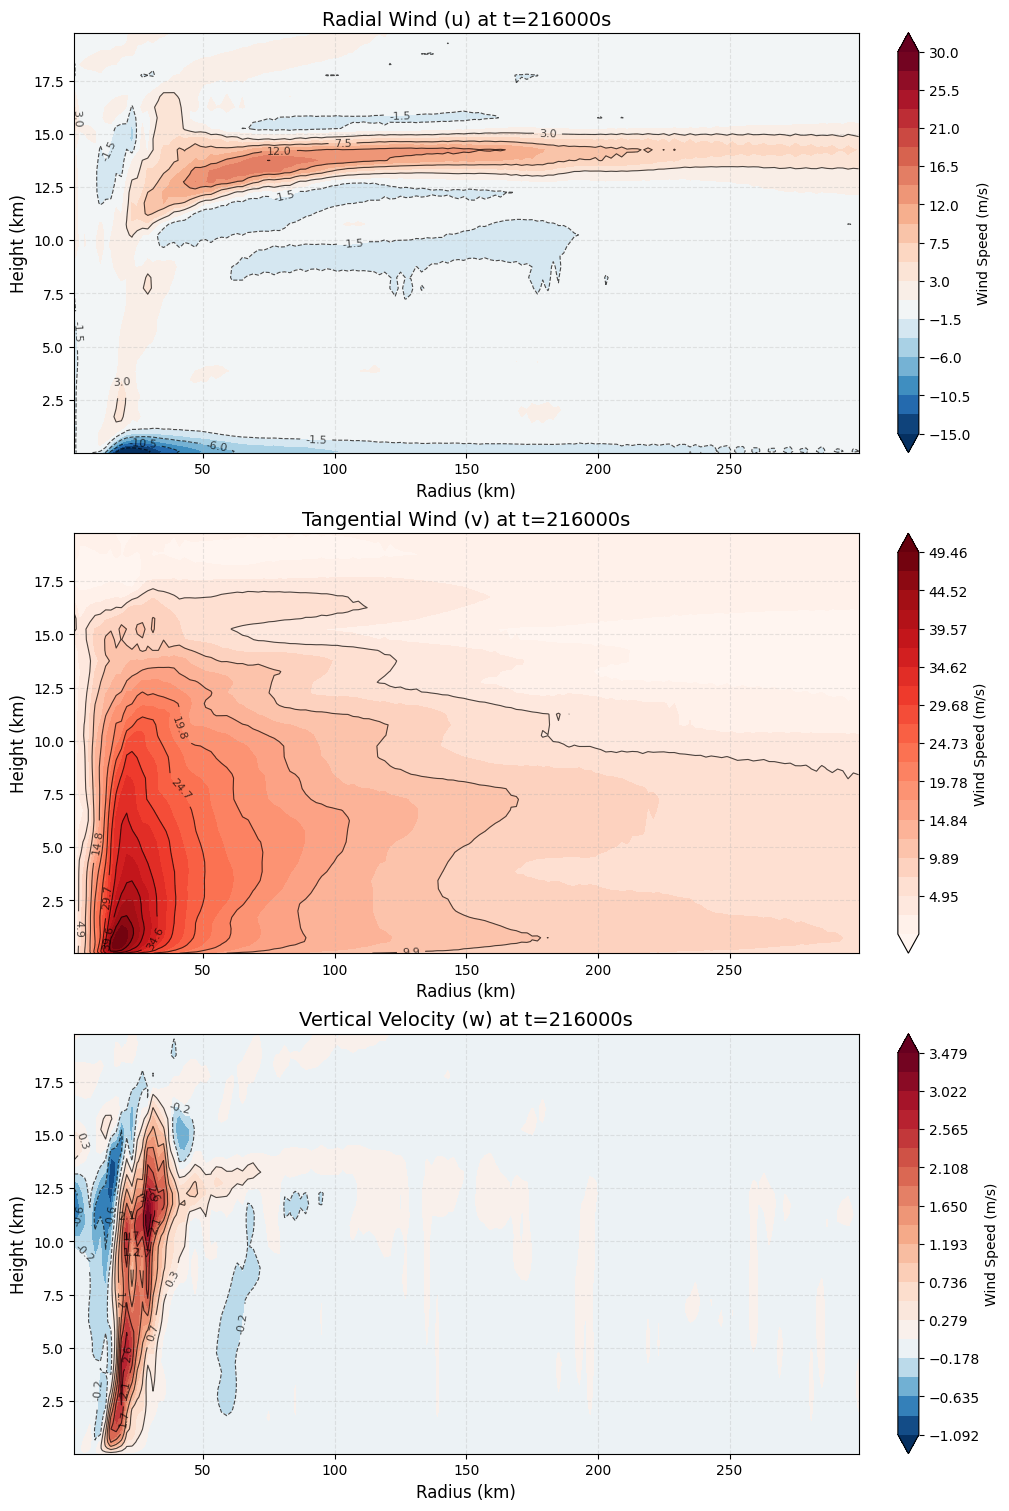

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import TwoSlopeNorm, PowerNorm

# --------------------------
# 1. 参数设置
# --------------------------
nc_file = r"dataset\typhoon_azimuthal_avg_budget_km.nc"  # 方位角平均后的数据文件
target_time = 3600*60    # 指定时间 (单位: 秒)
max_r_km = 300.0       # 最大绘图半径 (km)
max_z_km = 20.0         # 最大绘图高度 (km)

# 手动设置 Colorbar 范围 (格式: [min, max], 设为 None 则自动计算)
u_clim = [-15,30]   # 例如 [-20, 20]
v_clim = None   # 例如 [0, 80]
w_clim = None   # 例如 [-2, 2]

# 手动设置 Colorbar 渐变指数 (Gamma Correction)
u_gamma = 1.0 
v_gamma = 1.0 
w_gamma = 1.0

# --------------------------
# 2. 读取数据并筛选范围
# --------------------------
with Dataset(nc_file, 'r') as nc:
    # 读取坐标
    time_arr = nc.variables['time'][:]
    r_arr = nc.variables['r'][:]  # km
    z_arr = nc.variables['z'][:]  # km (假设单位是km，如果是m请除以1000)

    # 找到最近的时间索引
    t_idx = np.argmin(np.abs(time_arr - target_time))
    actual_time = time_arr[t_idx]
    print(f"目标时间: {target_time} s, 实际绘图时间: {actual_time} s (索引: {t_idx})")

    # 创建空间筛选掩码 (Mask)
    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    
    # 提取筛选后的坐标
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]
    
    # 提取对应时间、对应空间范围的数据
    u_data = nc.variables['ur'][t_idx, z_mask, r_mask]
    v_data = nc.variables['ut'][t_idx, z_mask, r_mask]
    w_data = nc.variables['w'][t_idx, z_mask, r_mask]

# --------------------------
# 3. 绘图逻辑
# --------------------------
# 创建网格
R, Z = np.meshgrid(r_plot, z_plot)

fig, axes = plt.subplots(3, 1, figsize=(10, 15), constrained_layout=True)

# 定义绘图列表配置
plot_configs = [
    {
        "data": u_data,
        "title": f"Radial Wind (u) at t={actual_time:.0f}s",
        "cmap": "RdBu_r",
        "ax": axes[0],
        "clim": u_clim,
        "gamma": u_gamma
    },
    {
        "data": v_data,
        "title": f"Tangential Wind (v) at t={actual_time:.0f}s",
        "cmap": "Reds",
        "ax": axes[1],
        "clim": v_clim,
        "gamma": v_gamma
    },
    {
        "data": w_data,
        "title": f"Vertical Velocity (w) at t={actual_time:.0f}s",
        "cmap": "RdBu_r",
        "ax": axes[2],
        "clim": w_clim,
        "gamma": w_gamma
    }
]

for config in plot_configs:
    ax = config["ax"]
    data = config["data"]
    gamma = config["gamma"]
    
    # 1. 确定 Colorbar 范围
    if config["clim"] is not None:
        vmin, vmax = config["clim"]
    else:
        vmin, vmax = np.min(data), np.max(data)

    # 2. 设置 Norm 和 Levels (用于 contourf)
    # 使用 contourf 需要指定 levels，这里生成 21 个层级以获得离散但平滑的效果
    n_levels = 21
    levels = np.linspace(vmin, vmax, n_levels)
    norm = None

    if config["cmap"] == "RdBu_r":
        # u, w: 0值对应白色，非对称范围
        # 确保 Norm 的中心在 0
        v_min_norm = min(vmin, -1e-5) # 确保小于0
        v_max_norm = max(vmax, 1e-5)  # 确保大于0
        norm = TwoSlopeNorm(vcenter=0, vmin=v_min_norm, vmax=v_max_norm)
        
    elif config["cmap"] == "Reds":
        # v: 0值对应白色
        vmin = 0 # 强制下限为 0
        if config["clim"] is not None: vmax = config["clim"][1]
        # 重新生成 levels 因为 vmin 变了
        levels = np.linspace(vmin, vmax, n_levels)
        
        if gamma != 1.0:
            norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

    # 3. 绘制填色图 (Contourf - 离散色块)
    # extend='both' 确保超出范围的值被正确着色
    cf = ax.contourf(R, Z, data, levels=levels, cmap=config["cmap"], norm=norm, extend='both')
    
    # 4. 绘制等值线 (Contour Lines)
    # 选取部分 levels 作为等值线，避免过密
    c_levels = levels[::2] 
    
    # 去除 0 等值线
    c_levels = c_levels[~np.isclose(c_levels, 0, atol=1e-5)]

    cs = ax.contour(R, Z, data, levels=c_levels, colors='k', linewidths=0.8, alpha=0.7)
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
    
    # 5. 设置标签和 Colorbar
    ax.set_title(config["title"], fontsize=14)
    ax.set_ylabel('Height (km)', fontsize=12)
    ax.set_xlabel('Radius (km)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 使用 contourf 对象生成 colorbar，会自动显示离散色块
    cbar = fig.colorbar(cf, ax=ax, label='Wind Speed (m/s)', ticks=c_levels)

plt.show()

数据源 1 实际时间 72.00h
数据源 2 实际时间 72.00h
数据源 3 实际时间 72.00h


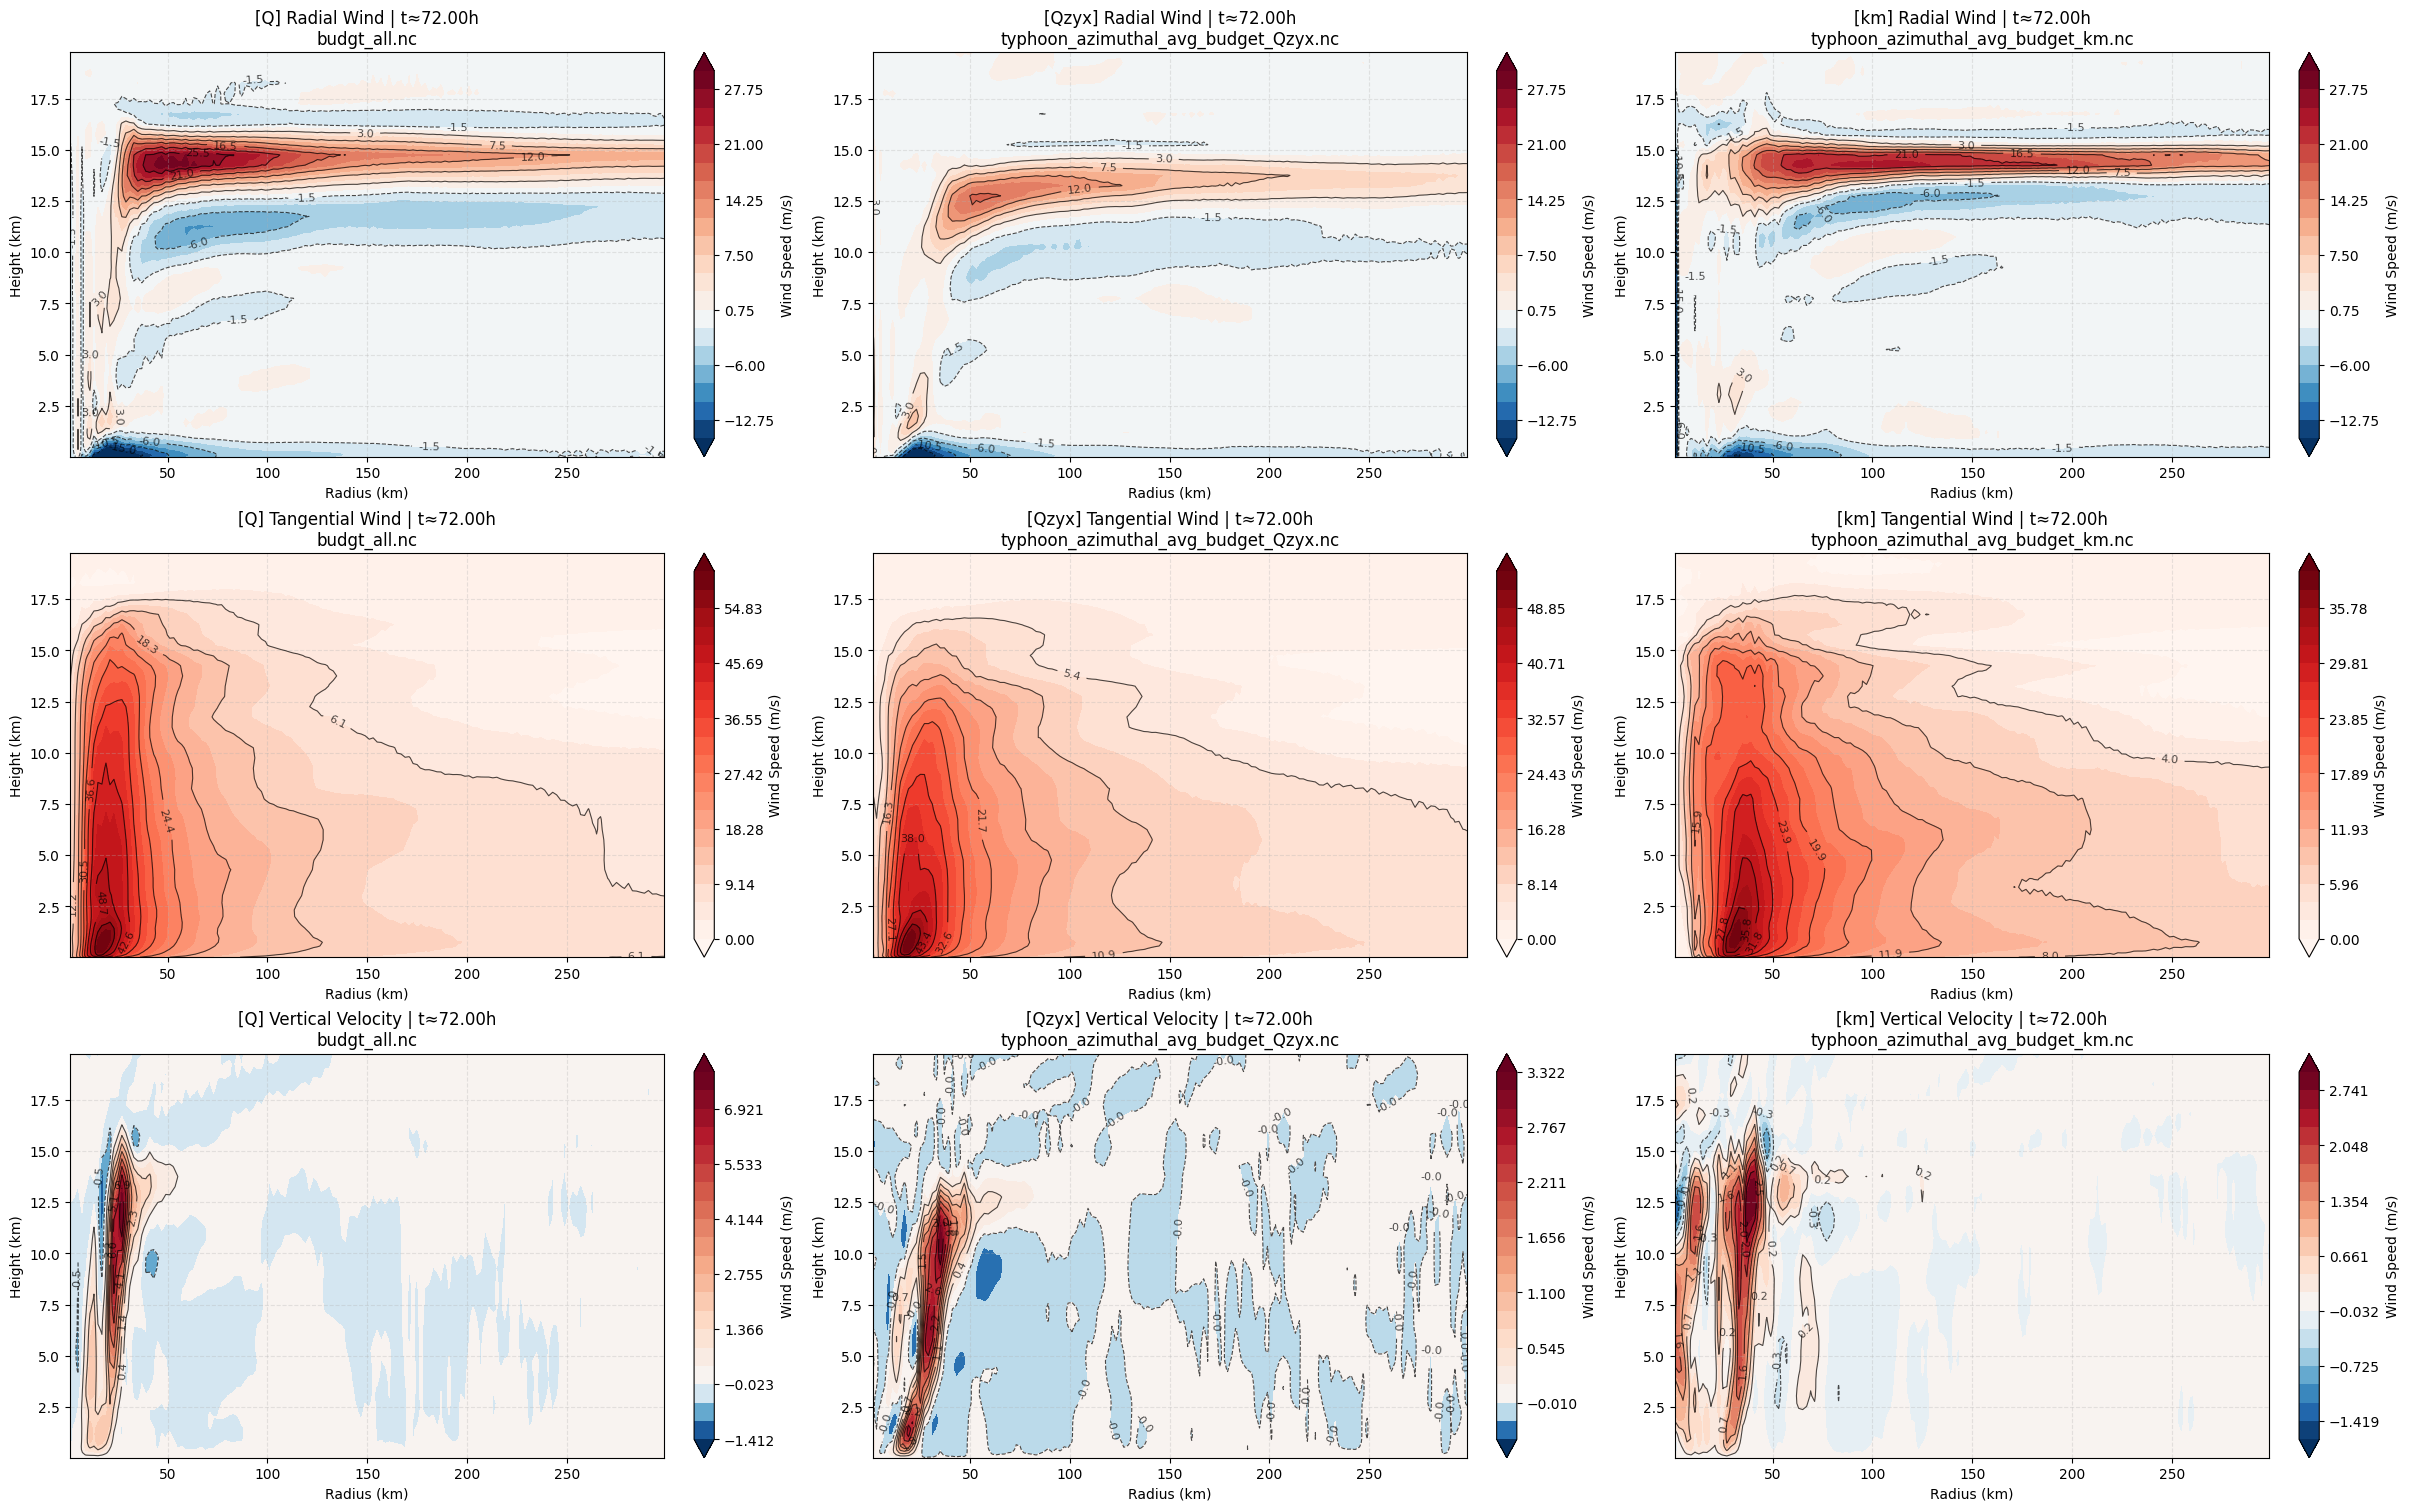

In [ ]:
import os
import site
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import TwoSlopeNorm, PowerNorm

# 清理 macOS 资源分叉文件，避免 matplotlib 样式读取报错
for sp in site.getsitepackages():
    pattern = os.path.join(sp, "matplotlib", "mpl-data", "stylelib", "._*.mplstyle")
    for bad_file in glob.glob(pattern):
        try:
            os.remove(bad_file)
        except OSError:
            pass

# --------------------------
# 1. 参数设置：时间与文件选项
# --------------------------
# 统一的时间选择 (单位: 小时)
target_time_hours = 72.0   

# 是否使用分别独立的时间? 如果为True, 将分别使用独立时间列表读取，否则统一使用 target_time_hours
use_independent_times = False

# 独立时间设置 (单位: 小时)，分别对应从左到右三个文件
independent_time_hours = [48.0, 72.0, 72.0]

# 文件列表 (从左到右三列图对应的数据源)
files = [
    r"dataset\wind_Thompson.nc",
    r"dataset\wind_Qzyx.nc",
    r"dataset\wind_km.nc"
]

# --------------------------
# 2. 绘图参设设置
# --------------------------
max_r_km = 300.0
max_z_km = 20.0

u_clim = [-15, 30]
v_clim = None
w_clim = None

u_gamma = 1.0
v_gamma = 1.0
w_gamma = 1.0

# --------------------------
# 3. 数据读取函数
# --------------------------
def load_fields(nc_file, target_time_s, max_r, max_z):
    if not os.path.exists(nc_file):
        print(f"[警告] 文件不存在: {nc_file}")
        return None
        
    with Dataset(nc_file, "r") as nc:
        time_arr = nc.variables["time"][:]
        r_arr = nc.variables["r"][:]
        z_arr = nc.variables["z"][:]

        t_idx = int(np.argmin(np.abs(time_arr - target_time_s)))
        actual_time = float(time_arr[t_idx])

        r_mask = r_arr <= max_r
        z_mask = z_arr <= max_z

        r_plot = r_arr[r_mask]
        z_plot = z_arr[z_mask]

        u_name = "ur" if "ur" in nc.variables else "u"
        v_name = "ut" if "ut" in nc.variables else "v"
        w_name = "w"

        u_data = nc.variables[u_name][t_idx, z_mask, r_mask]
        v_data = nc.variables[v_name][t_idx, z_mask, r_mask]
        w_data = nc.variables[w_name][t_idx, z_mask, r_mask]

    return {
        "file": nc_file,
        "actual_time": actual_time,
        "r": r_plot,
        "z": z_plot,
        "u": u_data,
        "v": v_data,
        "w": w_data,
    }

# --------------------------
# 4. 读取所有数据并绘图
# --------------------------
cases = []
for i, fpath in enumerate(files):
    t_hr = independent_time_hours[i] if use_independent_times else target_time_hours
    t_sec = t_hr * 3600.0
    case_data = load_fields(fpath, t_sec, max_r_km, max_z_km)
    if case_data is not None:
        print(f"数据源 {i+1} 实际时间 {case_data['actual_time']/3600.0:.2f}h")
    cases.append(case_data)

# 开始绘图: 3行(u,v,w) x 3列(三个文件数据)
fig, axes = plt.subplots(3, 3, figsize=(24, 15), constrained_layout=True)

plot_vars = [
    ("u", "Radial Wind", "RdBu_r", u_clim, u_gamma),
    ("v", "Tangential Wind", "Reds", v_clim, v_gamma),
    ("w", "Vertical Velocity", "RdBu_r", w_clim, w_gamma),
]

file_tags = ["Q", "Qzyx", "km"]

# 绘制矩阵图
for i, (var_key, title, cmap, clim, gamma) in enumerate(plot_vars):
    for j, case in enumerate(cases):
        ax = axes[i, j]
        if case is None:
            ax.set_title(f"[{file_tags[j]}] File Not Found")
            ax.axis('off')
            continue
            
        data = np.asarray(case[var_key])
        R, Z = np.meshgrid(case["r"], case["z"])

        if clim is not None:
            vmin, vmax = float(clim[0]), float(clim[1])
        else:
            vmin, vmax = float(np.nanmin(data)), float(np.nanmax(data))

        n_levels = 21
        levels = np.linspace(vmin, vmax, n_levels)
        norm = None

        if cmap == "RdBu_r":
            v_min_norm = min(vmin, -1e-5)
            v_max_norm = max(vmax, 1e-5)
            norm = TwoSlopeNorm(vcenter=0, vmin=v_min_norm, vmax=v_max_norm)
        elif cmap == "Reds":
            vmin = 0.0
            if clim is not None:
                vmax = float(clim[1])
            levels = np.linspace(vmin, vmax, n_levels)
            if gamma != 1.0:
                norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

        cf = ax.contourf(R, Z, data, levels=levels, cmap=cmap, norm=norm, extend="both")

        c_levels = levels[::2]
        c_levels = c_levels[~np.isclose(c_levels, 0, atol=1e-5)]
        if c_levels.size > 0:
            cs = ax.contour(R, Z, data, levels=c_levels, colors="k", linewidths=0.8, alpha=0.7)
            ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

        case_name = os.path.basename(case['file'])
        ax.set_title(
            f"[{file_tags[j]}] {title} | t≈{case['actual_time']/3600.0:.2f}h\n{case_name}",
            fontsize=12
        )
        ax.set_ylabel("Height (km)")
        ax.set_xlabel("Radius (km)")
        ax.grid(True, linestyle="--", alpha=0.3)
        fig.colorbar(cf, ax=ax, label="Wind Speed (m/s)")

plt.show()

In [1]:
import os
import site
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import TwoSlopeNorm, PowerNorm

# 清理 macOS 资源分叉文件，避免 matplotlib 样式读取报错
for sp in site.getsitepackages():
    pattern = os.path.join(sp, "matplotlib", "mpl-data", "stylelib", "._*.mplstyle")
    for bad_file in glob.glob(pattern):
        try:
            os.remove(bad_file)
        except OSError:
            pass

# --------------------------
# 1. 批量保存参数设置
# --------------------------
# 创建输出文件夹
output_dir = "figure_az_avg"
os.makedirs(output_dir, exist_ok=True)

# 批量绘制的时间范围 (单位: 小时)
start_time_hr = 40.0
end_time_hr = 47.0
time_step_hr = 1.0  # 绘图时间间隔（根据您的输出频率，可修改为 1.0, 3.0 等）

# 文件列表 (从左到右三列图对应的数据源)
files = [
    r"dataset\wind_Thompson.nc",
    r"dataset\wind_Qzyx.nc",
    r"dataset\wind_km.nc"
]
file_tags = ["Thompson", "Qzyx", "km"]

# --------------------------
# 2. 绘图参设设置
# --------------------------
max_r_km = 300.0
max_z_km = 20.0

u_clim = [-15, 30]
v_clim = None
w_clim = None

u_gamma = 1.0
v_gamma = 1.0
w_gamma = 1.0

# --------------------------
# 3. 数据读取函数
# --------------------------
def load_fields(nc_file, target_time_s, max_r, max_z):
    if not os.path.exists(nc_file):
        return None
        
    with Dataset(nc_file, "r") as nc:
        time_arr = nc.variables["time"][:]
        r_arr = nc.variables["r"][:]
        z_arr = nc.variables["z"][:]

        t_idx = int(np.argmin(np.abs(time_arr - target_time_s)))
        actual_time = float(time_arr[t_idx])

        r_mask = r_arr <= max_r
        z_mask = z_arr <= max_z

        r_plot = r_arr[r_mask]
        z_plot = z_arr[z_mask]

        u_name = "ur" if "ur" in nc.variables else "u"
        v_name = "ut" if "ut" in nc.variables else "v"
        w_name = "w"

        u_data = nc.variables[u_name][t_idx, z_mask, r_mask]
        v_data = nc.variables[v_name][t_idx, z_mask, r_mask]
        w_data = nc.variables[w_name][t_idx, z_mask, r_mask]

    return {
        "file": nc_file,
        "actual_time": actual_time,
        "r": r_plot,
        "z": z_plot,
        "u": u_data,
        "v": v_data,
        "w": w_data,
    }

# --------------------------
# 4. 批量绘图及保存逻辑
# --------------------------
time_array = np.arange(start_time_hr, end_time_hr + 1e-5, time_step_hr)

plot_vars = [
    ("u", "Radial Wind", "RdBu_r", u_clim, u_gamma),
    ("v", "Tangential Wind", "Reds", v_clim, v_gamma),
    ("w", "Vertical Velocity", "RdBu_r", w_clim, w_gamma),
]

for t_hr in time_array:
    print(f"正在处理 {t_hr}h 的图像 ...")
    
    # 1. 尝试读取数据
    cases = []
    has_valid_data = False
    for fpath in files:
        t_sec = t_hr * 3600.0
        case_data = load_fields(fpath, t_sec, max_r_km, max_z_km)
        cases.append(case_data)
        if case_data is not None:
            has_valid_data = True
            
    if not has_valid_data:
        print(f"  [跳过] {t_hr}h 没有找到任何有效数据以供渲染。")
        continue

    # 2. 生成画布
    fig, axes = plt.subplots(3, 3, figsize=(24, 15), constrained_layout=True)

    # 3. 绘制矩阵图
    for i, (var_key, title, cmap, clim, gamma) in enumerate(plot_vars):
        for j, case in enumerate(cases):
            ax = axes[i, j]
            if case is None:
                ax.set_title(f"[{file_tags[j]}] File Not Found\nt={t_hr}h")
                ax.axis('off')
                continue
                
            data = np.asarray(case[var_key])
            R, Z = np.meshgrid(case["r"], case["z"])

            if clim is not None:
                vmin, vmax = float(clim[0]), float(clim[1])
            else:
                vmin, vmax = float(np.nanmin(data)), float(np.nanmax(data))

            n_levels = 21
            levels = np.linspace(vmin, vmax, n_levels)
            norm = None

            if cmap == "RdBu_r":
                v_min_norm = min(vmin, -1e-5)
                v_max_norm = max(vmax, 1e-5)
                norm = TwoSlopeNorm(vcenter=0, vmin=v_min_norm, vmax=v_max_norm)
            elif cmap == "Reds":
                vmin = 0.0
                if clim is not None:
                    vmax = float(clim[1])
                levels = np.linspace(vmin, vmax, n_levels)
                if gamma != 1.0:
                    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

            cf = ax.contourf(R, Z, data, levels=levels, cmap=cmap, norm=norm, extend="both")

            c_levels = levels[::2]
            c_levels = c_levels[~np.isclose(c_levels, 0, atol=1e-5)]
            if c_levels.size > 0:
                cs = ax.contour(R, Z, data, levels=c_levels, colors="k", linewidths=0.8, alpha=0.7)
                ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

            case_name = os.path.basename(case['file'])
            actual_hr = case['actual_time'] / 3600.0
            ax.set_title(
                f"[{file_tags[j]}] {title} | t≈{actual_hr:.2f}h\n{case_name}",
                fontsize=12
            )
            ax.set_ylabel("Height (km)")
            ax.set_xlabel("Radius (km)")
            ax.grid(True, linestyle="--", alpha=0.3)
            fig.colorbar(cf, ax=ax, label="Wind Speed (m/s)")

    # 4. 保存图像并释放内存
    output_filename = os.path.join(output_dir, f"az_avg_{t_hr:03.0f}h.png")
    fig.savefig(output_filename, dpi=150, bbox_inches='tight')
    plt.close(fig) # 重点：必须关闭图表，以防内存泄漏
    
    print(f"  -> 已保存: {output_filename}")

print("批量渲染并保存完成！")

正在处理 40.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_040h.png
正在处理 41.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_041h.png
正在处理 42.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_042h.png
正在处理 43.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_043h.png
正在处理 44.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_044h.png
正在处理 45.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_045h.png
正在处理 46.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_046h.png
正在处理 47.0h 的图像 ...
  -> 已保存: figure_az_avg\az_avg_047h.png
批量渲染并保存完成！


In [ ]:
import os
import glob
import cv2

# 参数设置
image_folder = 'figure_az_avg'
video_name = 'az_avg_animation.mp4'
fps = 15  # 每秒 15 帧

# 获取所有生成的图片并按文件名排序
images = glob.glob(os.path.join(image_folder, "az_avg_*.png"))
images.sort()

if not images:
    print(f"在 {image_folder} 文件夹中没有找到图片，请检查路径。")
else:
    # 读取第一张图片获取宽高信息
    frame = cv2.imread(images[0])
    height, width, layers = frame.shape

    # 设置视频写入参数
    # 'mp4v' 编码通常用于 mp4 格式
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(video_name, fourcc, fps, (width, height))

    print(f"开始生成视频，共 {len(images)} 帧...")
    for image in images:
        video.write(cv2.imread(image))

    # 释放资源
    video.release()
    print(f"视频生成完成！已保存为: {video_name}")